# Match Time Series Analysis

Two views of match dynamics using time-bucketed metrics:

- **Section 1** — Single Match Inspector: per-team attack depth and death rate over absolute match time.
- **Section 2** — Aggregate Per-Map View: all matches on a map overlaid on normalized time `[0, 1]`.
- **Section 3** — Push-Pull Summary: Pearson correlation between teams' attack depths (map quality metric).

**Timestamp note:** All event timestamps in the database are elapsed seconds since match start.
`position_events.timestamp` is therefore used directly as `tick_t_s` — no conversion required.

In [1]:
import os, sys
# Change to repo root so all relative paths resolve correctly.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import json
import math
import duckdb
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

# ── Global tunables ───────────────────────────────────────────────────────────
BUCKET_SIZE_S        = 60     # bucket width in seconds (used across all sections)
PUSH_DEPTH_THRESHOLD = 0.65   # min graph depth (0–1) to count a player as a pusher
PUSH_MIN_PLAYERS     = 2      # simultaneous pushers required for a coordinated push window
OUTPUT_DIR           = Path("output")
DB_PATH              = Path("match_analysis/metadata.db")

OUTPUT_DIR.mkdir(exist_ok=True)
print(
    f"DuckDB: {DB_PATH}  |  bucket: {BUCKET_SIZE_S}s  |  "
    f"push threshold: {PUSH_DEPTH_THRESHOLD:.0%}  |  min players: {PUSH_MIN_PLAYERS}"
)

DuckDB: match_analysis\metadata.db  |  bucket: 60s  |  push threshold: 65%  |  min players: 2


In [2]:
# ── Helper: DB connection ─────────────────────────────────────────────────────

def open_db(read_only=True):
    return duckdb.connect(str(DB_PATH), read_only=read_only)


# ── Helper: team colors ───────────────────────────────────────────────────────

_MINECRAFT_COLORS = {
    "dark_red":    "#AA0000", "dark red":    "#AA0000",
    "red":         "#FF5555",
    "gold":        "#FFAA00",
    "yellow":      "#DDDD00",
    "dark_green":  "#00AA00", "dark green":  "#00AA00",
    "green":       "#55FF55",
    "aqua":        "#55FFFF",
    "dark_aqua":   "#00AAAA", "dark aqua":   "#00AAAA",
    "dark_blue":   "#0000AA", "dark blue":   "#0000AA",
    "blue":        "#5555FF",
    "light_purple":"#FF55FF", "light purple":"#FF55FF",
    "dark_purple": "#AA00AA", "dark purple": "#AA00AA",
    "white":       "#FFFFFF",
    "gray":        "#AAAAAA",
    "dark_gray":   "#555555", "dark gray":   "#555555",
    "black":       "#000000",
}

_WOOL_PALETTE = {
    "cyan": "#00BBCC", "lime": "#44CC44", "orange": "#FFA500",
    "yellow": "#DDDD00", "red": "#FF5555", "blue": "#5555FF",
    "white": "#CCCCCC", "purple": "#AA00AA", "green": "#55FF55",
    "magenta": "#FF55FF", "pink": "#FF99CC", "gray": "#888888",
    "light_gray": "#BBBBBB", "brown": "#AA7733", "black": "#333333",
}

def get_team_colors(conn, map_id: int) -> dict:
    """Return {normalized_team: hex_color} for a map."""
    rows = conn.execute(
        "SELECT team, team_color FROM map_spawns WHERE map_id = ?", [map_id]
    ).fetchall()
    tab10 = [matplotlib.colors.to_hex(c) for c in plt.get_cmap("tab10").colors]
    colors, tab10_idx = {}, 0
    for team_raw, color_raw in rows:
        team = team_raw.removesuffix("-team")
        hex_color = _MINECRAFT_COLORS.get(color_raw)
        if hex_color is None:
            try:
                hex_color = matplotlib.colors.to_hex(color_raw)
            except ValueError:
                hex_color = tab10[tab10_idx % len(tab10)]
                tab10_idx += 1
        colors[team] = hex_color
    return colors


# ── Helper: graph topology ────────────────────────────────────────────────────

def build_graph_topology(map_slug: str) -> dict:
    """Build per-island skeleton graphs and Dijkstra depth lookups.

    Loads map_graph.json and constructs a weighted NetworkX graph per island
    using Euclidean distances between connected skeleton nodes.

    Returns a dict with:
      node_info      : {map_node_id: full node dict}
      island_graphs  : {island_id: nx.Graph with Euclidean edge weights}
      wool_nodes     : list of node dicts where poi_type == 'wool'
      spawn_nodes    : list of node dicts where poi_type == 'spawn'
      dijkstra_dists : {wool_map_node_id: {map_node_id: graph_dist_from_wool}}
      wool_baselines : {wool_map_node_id: max_graph_dist_on_island}  (normalisation)
    """
    import networkx as nx

    with open(OUTPUT_DIR / map_slug / "map_graph.json") as f:
        mg = json.load(f)

    global_nodes = mg["map_graph"]["nodes"]

    # (island_id, local_node_id) → global map_node_id
    local_to_global = {
        (n["island_id"], n["local_node_id"]): n["map_node_id"]
        for n in global_nodes
    }
    node_info = {n["map_node_id"]: n for n in global_nodes}

    # Per-island weighted graph using per-island skeleton edges
    island_graphs: dict = {}
    for isl in mg["islands"]:
        isl_id = isl["island_id"]
        skel = isl["skeleton"]
        nodes_by_local = {n["node_id"]: n for n in skel["nodes"]}

        G = nx.Graph()
        for n in skel["nodes"]:
            gid = local_to_global.get((isl_id, n["node_id"]))
            if gid is not None:
                G.add_node(gid, x=n["x"], z=n["z"], node_type=n["type"])

        for e in skel["edges"]:
            src_gid = local_to_global.get((isl_id, e["src"]))
            dst_gid = local_to_global.get((isl_id, e["dst"]))
            if src_gid is not None and dst_gid is not None:
                sn, dn = nodes_by_local[e["src"]], nodes_by_local[e["dst"]]
                w = math.sqrt((sn["x"] - dn["x"]) ** 2 + (sn["z"] - dn["z"]) ** 2)
                G.add_edge(src_gid, dst_gid, weight=w)

        island_graphs[isl_id] = G

    wool_nodes  = [n for n in global_nodes if n.get("poi_type") == "wool"]
    spawn_nodes = [n for n in global_nodes if n.get("poi_type") == "spawn"]

    # Dijkstra from each wool node within its island skeleton
    dijkstra_dists: dict = {}
    for wn in wool_nodes:
        wid = wn["map_node_id"]
        G = island_graphs.get(wn["island_id"])
        if G is None or wid not in G:
            continue
        dijkstra_dists[wid] = nx.single_source_dijkstra_path_length(
            G, wid, weight="weight"
        )

    # Baseline = max Dijkstra distance from wool to any node on same island
    wool_baselines = {
        wid: (max(d.values()) if d else 1.0)
        for wid, d in dijkstra_dists.items()
    }

    return {
        "node_info":       node_info,
        "local_to_global": local_to_global,
        "island_graphs":   island_graphs,
        "wool_nodes":      wool_nodes,
        "spawn_nodes":     spawn_nodes,
        "dijkstra_dists":  dijkstra_dists,
        "wool_baselines":  wool_baselines,
    }


# ── Helper: per-tick graph depth ──────────────────────────────────────────────

def add_graph_depth(pos_df: pd.DataFrame, topo: dict) -> pd.DataFrame:
    """Add per-wool graph depth columns using the island skeleton graph.

    Depth is computed only for players physically ON the wool's island, using
    nearest_graph_node (island-scoped) and Dijkstra distances from the wool node.
    Players on bridges, their own island, or neutral islands receive depth 0 —
    they are not yet contesting the objective.

    Adds columns:
      depth_<wool_color>  one column per wool
      depth_max           max over enemy wools for that player's team per tick
    """
    result     = pos_df.copy()
    wool_nodes = topo["wool_nodes"]
    dijk       = topo["dijkstra_dists"]
    baselines  = topo["wool_baselines"]
    all_teams  = sorted(result["team"].dropna().unique())

    for wn in wool_nodes:
        wid      = wn["map_node_id"]
        col      = f"depth_{wn['poi_color']}"
        wsl_id   = wn["island_id"]
        depths   = np.zeros(len(result))

        if wid in dijk:
            d_map    = dijk[wid]
            baseline = baselines.get(wid, 1.0)
            on_isl   = (
                (result["location_type"] == "island")
                & (result["island_id"] == wsl_id)
                & result["nearest_graph_node"].notna()
            )
            if on_isl.any():
                nids = result.loc[on_isl, "nearest_graph_node"].astype(int)
                depths[on_isl.values] = np.clip(
                    1.0 - np.array([d_map.get(n, baseline) for n in nids]) / baseline,
                    0.0, 1.0,
                )

        result[col] = depths

    # depth_max = max over enemy wools for the player's attacking team
    result["depth_max"] = 0.0
    for team in all_teams:
        t_mask      = result["team"] == team
        enemy_wools = [wn for wn in wool_nodes if wn["team"] != team]
        if not enemy_wools:
            continue
        enemy_cols = [f"depth_{wn['poi_color']}" for wn in enemy_wools]
        result.loc[t_mask, "depth_max"] = result.loc[t_mask, enemy_cols].max(axis=1)

    return result


# ── Helper: load match data ───────────────────────────────────────────────────

def load_match_data(conn, match_id: int) -> dict:
    """Load positions, deaths, and wool events for a match."""
    meta = conn.execute(
        "SELECT mat.match_id, mat.map_id, mat.match_duration, m.map_slug "
        "FROM matches mat JOIN maps m ON mat.map_id = m.map_id "
        "WHERE match_id = ?", [match_id]
    ).fetchone()
    if meta is None:
        raise ValueError(f"Match {match_id} not found")
    _, map_id, match_duration_s, map_slug = meta

    pos_df = conn.execute("""
        SELECT
            pe.player_id,
            pe.timestamp          AS tick_t_s,
            pe.x, pe.z,
            pe.location_type,
            pe.island_id,
            pe.nearest_graph_node,
            pts.team
        FROM position_events pe
        LEFT JOIN player_team_segments pts
            ON  pts.player_id        = pe.player_id
            AND pts.match_id         = pe.match_id
            AND pts.start_timestamp <= pe.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= pe.timestamp)
        WHERE pe.match_id = ?
        ORDER BY pe.player_id, pe.timestamp
    """, [match_id]).df()

    death_df = conn.execute("""
        SELECT ce.timestamp AS tick_t_s, pts.team
        FROM combat_events ce
        LEFT JOIN player_team_segments pts
            ON  pts.player_id        = ce.player_id
            AND pts.match_id         = ce.match_id
            AND pts.start_timestamp <= ce.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= ce.timestamp)
        WHERE ce.match_id = ? AND ce.event_type = 4
    """, [match_id]).df()

    wool_df = conn.execute("""
        SELECT we.timestamp AS tick_t_s, we.event_type, we.wool_id, pts.team
        FROM wool_events we
        LEFT JOIN player_team_segments pts
            ON  pts.player_id        = we.player_id
            AND pts.match_id         = we.match_id
            AND pts.start_timestamp <= we.timestamp
            AND (pts.end_timestamp IS NULL OR pts.end_timestamp >= we.timestamp)
        WHERE we.match_id = ?
    """, [match_id]).df()

    return {
        "match_id":         match_id,
        "map_id":           map_id,
        "map_slug":         map_slug,
        "match_duration_s": match_duration_s,
        "pos":              pos_df,
        "deaths":           death_df,
        "wool":             wool_df,
    }


# ── Helper: pusher counts per bucket ──────────────────────────────────────────

def compute_pusher_counts(
    data:           dict,
    topo:           dict,
    bucket_size_s:  int   = BUCKET_SIZE_S,
    threshold:      float = PUSH_DEPTH_THRESHOLD,
    norm:           bool  = False,
    n_norm_buckets: int   = 50,
) -> pd.DataFrame:
    """Count distinct players above depth threshold per team, wool, and bucket.

    Returns DataFrame with columns:
      team, wool_color, bucket, pusher_count, death_count, death_rate,
      bucket_mid_s (absolute) or bucket_norm_mid (normalised)
    """
    pos_df    = add_graph_depth(data["pos"].copy(), topo)
    death_df  = data["deaths"].copy()
    match_dur = data["match_duration_s"]
    wool_nodes = topo["wool_nodes"]

    if norm:
        pos_df["bucket"]   = np.minimum(
            (pos_df["tick_t_s"] / match_dur * n_norm_buckets).astype(int),
            n_norm_buckets - 1,
        )
        death_df["bucket"] = np.minimum(
            (death_df["tick_t_s"] / match_dur * n_norm_buckets).astype(int),
            n_norm_buckets - 1,
        )
        bin_width = match_dur / n_norm_buckets
    else:
        pos_df["bucket"]   = (pos_df["tick_t_s"] // bucket_size_s).astype(int)
        death_df["bucket"] = (death_df["tick_t_s"] // bucket_size_s).astype(int)
        bin_width = bucket_size_s

    death_counts = (
        death_df.groupby(["team", "bucket"]).size()
        .rename("death_count").reset_index()
    )

    records = []
    all_atk_teams = sorted(pos_df["team"].dropna().unique())
    for wn in wool_nodes:
        wool_color = wn["poi_color"]
        def_team   = wn["team"]
        depth_col  = f"depth_{wool_color}"
        atk_teams  = [t for t in all_atk_teams if t != def_team]

        for atk_team in atk_teams:
            sub = pos_df[
                (pos_df["team"] == atk_team) & (pos_df[depth_col] > threshold)
            ].copy()
            if sub.empty:
                continue
            counts = (
                sub.groupby("bucket")["player_id"]
                .nunique().rename("pusher_count").reset_index()
            )
            counts["team"]       = atk_team
            counts["wool_color"] = wool_color
            records.append(counts)

    df = (
        pd.concat(records, ignore_index=True) if records
        else pd.DataFrame(columns=["team", "wool_color", "bucket", "pusher_count"])
    )
    df = df.merge(death_counts, on=["team", "bucket"], how="left")
    df["death_count"] = df["death_count"].fillna(0)
    df["death_rate"]  = df["death_count"] / bin_width

    if norm:
        df["bucket_norm_mid"] = (df["bucket"] + 0.5) / n_norm_buckets
    else:
        df["bucket_mid_s"] = (df["bucket"] + 0.5) * bucket_size_s

    return df

## Section 1 — Single Match Inspector

One panel per team showing:
- **Left y-axis:** count of players above `PUSH_DEPTH_THRESHOLD` graph depth, per enemy wool (coloured by wool).  
  Graph depth is computed within the enemy island's skeleton — only players physically on the wool's island contribute; bridge/home-island players always score 0.
- **Right y-axis (dashed):** death rate (deaths/second).
- **Grey dotted line:** coordinated push threshold (`PUSH_MIN_PLAYERS`).
- **Event markers:** ▲ wool touches, ★ wool captures.

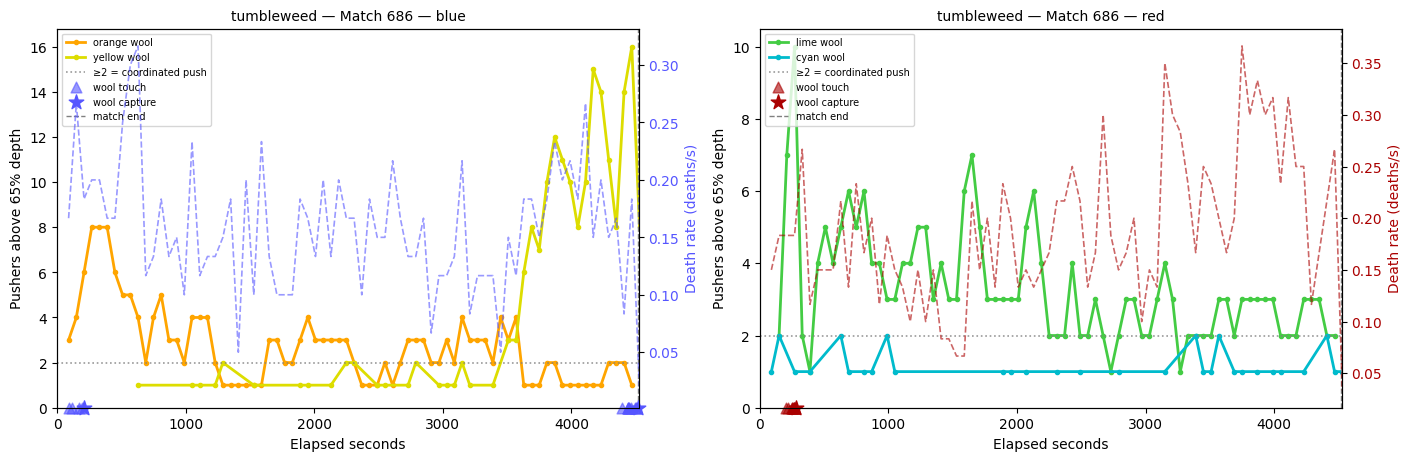

Saved: output\pushers_match_686.png


In [3]:
# ── CONFIGURE ─────────────────────────────────────────────────────────────────
INSPECT_MATCH_ID = 686   # change to inspect any match
# ─────────────────────────────────────────────────────────────────────────────

conn   = open_db()
data   = load_match_data(conn, INSPECT_MATCH_ID)
topo   = build_graph_topology(data["map_slug"])
colors = get_team_colors(conn, data["map_id"])
conn.close()

counts           = compute_pusher_counts(data, topo, bucket_size_s=BUCKET_SIZE_S)
teams            = sorted(counts["team"].dropna().unique())
match_duration_s = data["match_duration_s"]
map_slug         = data["map_slug"]
wool_nodes       = topo["wool_nodes"]

ncols = min(len(teams), 3)
nrows = math.ceil(len(teams) / ncols)
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(7 * ncols, 4.5 * nrows),
    constrained_layout=True,
    squeeze=False,
)

for ax_idx, team in enumerate(teams):
    row, col = divmod(ax_idx, ncols)
    ax  = axes[row][col]
    ax2 = ax.twinx()
    tc  = colors.get(team, "#888888")

    enemy_wools = [wn for wn in wool_nodes if wn["team"] != team]

    for wn in enemy_wools:
        wool_color = wn["poi_color"]
        wc = _WOOL_PALETTE.get(wool_color, "#AAAAAA")
        sub = counts[
            (counts["team"] == team) & (counts["wool_color"] == wool_color)
        ].sort_values("bucket_mid_s")
        if not sub.empty:
            ax.plot(
                sub["bucket_mid_s"], sub["pusher_count"],
                color=wc, lw=2, marker="o", markersize=3,
                label=f"{wool_color} wool",
            )

    # Death rate on right axis
    death_sub = (
        counts[counts["team"] == team]
        .sort_values("bucket_mid_s")
        .drop_duplicates("bucket")
    )
    if not death_sub.empty:
        ax2.plot(
            death_sub["bucket_mid_s"], death_sub["death_rate"],
            color=tc, lw=1.2, ls="--", alpha=0.6, label="death rate",
        )

    # Threshold line
    ax.axhline(
        PUSH_MIN_PLAYERS, color="grey", ls=":", lw=1.2, alpha=0.8,
        label=f"≥{PUSH_MIN_PLAYERS} = coordinated push",
    )

    # Wool event markers
    wool_team = data["wool"][data["wool"]["team"] == team]
    touches  = wool_team[wool_team["event_type"] == 6]["tick_t_s"].values
    captures = wool_team[wool_team["event_type"] == 7]["tick_t_s"].values
    if len(touches):
        ax.scatter(
            touches, [0.0] * len(touches),
            marker="^", color=tc, s=60, alpha=0.6, zorder=5, clip_on=False,
            label="wool touch",
        )
    if len(captures):
        ax.scatter(
            captures, [0.0] * len(captures),
            marker="*", color=tc, s=120, zorder=6, clip_on=False,
            label="wool capture",
        )

    ax.axvline(match_duration_s, color="grey", ls="--", lw=1, label="match end")
    ax.set_xlim(0, match_duration_s + 5)
    ax.set_ylim(bottom=0)   # auto-scale top; let data determine max
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel("Elapsed seconds")
    ax.set_ylabel(f"Pushers above {PUSH_DEPTH_THRESHOLD:.0%} depth")
    ax2.set_ylabel("Death rate (deaths/s)", color=tc)
    ax2.tick_params(axis="y", labelcolor=tc)
    ax.set_title(f"{map_slug} — Match {INSPECT_MATCH_ID} — {team}", fontsize=10)
    ax.legend(loc="upper left", fontsize=7)

for ax_idx in range(len(teams), nrows * ncols):
    row, col = divmod(ax_idx, ncols)
    axes[row][col].set_visible(False)

out_path = OUTPUT_DIR / f"pushers_match_{INSPECT_MATCH_ID}.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 2 — Aggregate Per-Map View

All matches for a map overlaid on normalized time `[0, 1]`:
- Individual matches as faint lines.
- **Bold line:** median attack depth per norm bucket.
- **Shaded band:** 25th–75th percentile.
- **Rug marks:** wool captures below x-axis, jittered in y.
- **Third panel:** match duration histogram.

Map: tumbleweed  |  1 eligible match(es)


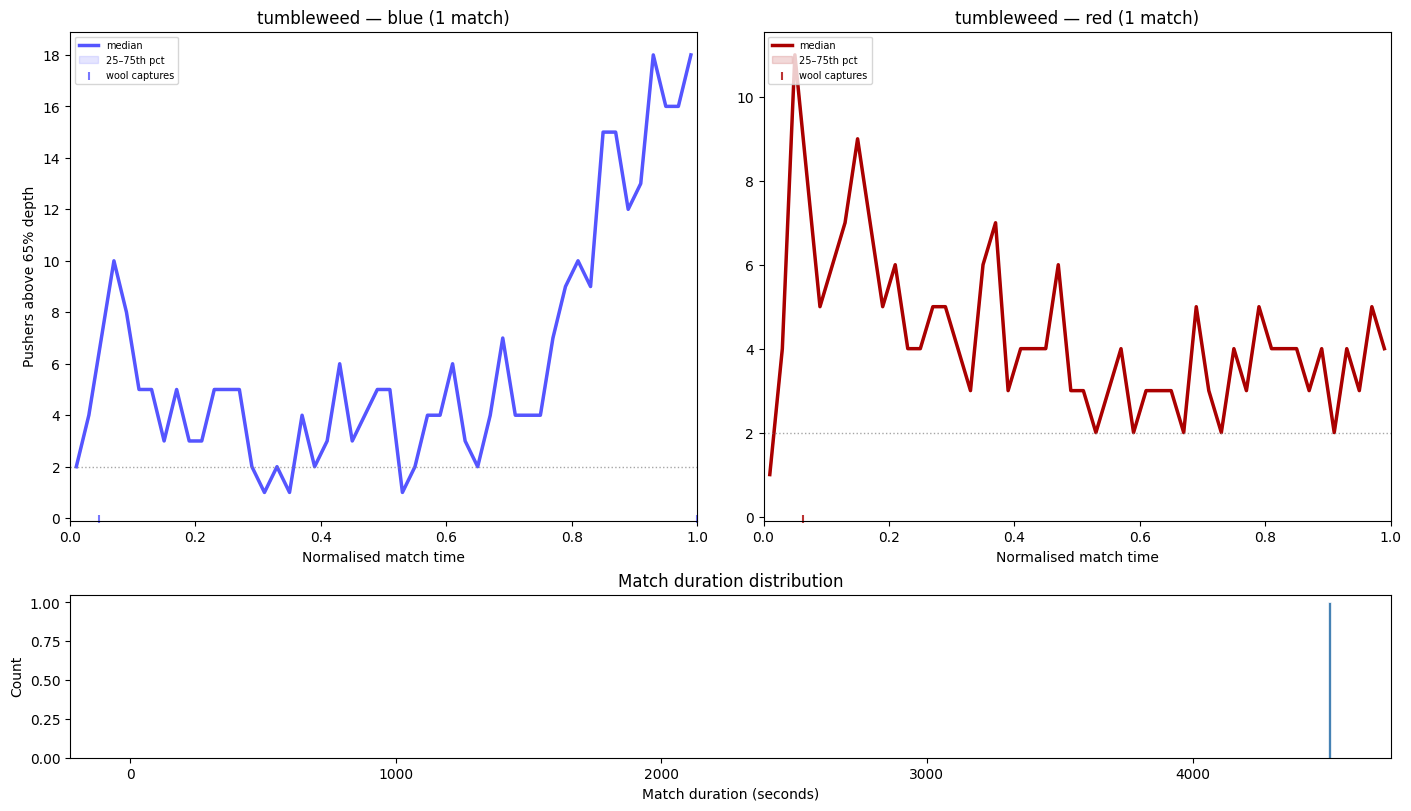

Saved: output\pushers_aggregate_tumbleweed.png


In [4]:
# ── CONFIGURE ─────────────────────────────────────────────────────────────────
AGGREGATE_MAP_SLUG   = "tumbleweed"
MIN_MATCH_DURATION_S = 120
MAX_MATCHES          = None
N_NORM_BUCKETS       = 50
HIST_BIN_S           = 10
# ─────────────────────────────────────────────────────────────────────────────

conn = open_db()

map_row = conn.execute(
    "SELECT map_id FROM maps WHERE map_slug = ?", [AGGREGATE_MAP_SLUG]
).fetchone()
if map_row is None:
    raise ValueError(f"Map '{AGGREGATE_MAP_SLUG}' not in database")
agg_map_id     = map_row[0]
team_colors_agg = get_team_colors(conn, agg_map_id)

match_rows = conn.execute("""
    SELECT match_id, match_duration
    FROM matches
    WHERE map_id = ? AND processed = TRUE AND match_duration >= ?
    ORDER BY match_id
""", [agg_map_id, MIN_MATCH_DURATION_S]).fetchall()

if MAX_MATCHES:
    match_rows = match_rows[:MAX_MATCHES]

print(f"Map: {AGGREGATE_MAP_SLUG}  |  {len(match_rows)} eligible match(es)")
match_durations = [r[1] for r in match_rows]

# Build graph topology once (shared across all matches on this map)
agg_topo = build_graph_topology(AGGREGATE_MAP_SLUG)

# Accumulate per-match normalised pusher-count series
# Structure: {team: list of arrays shape (N_NORM_BUCKETS,)}  (summed over enemy wools)
series_by_team = {}
wool_cap_norm_by_team = {}

for match_id, _ in match_rows:
    mdata   = load_match_data(conn, match_id)
    mcounts = compute_pusher_counts(
        mdata, agg_topo, norm=True, n_norm_buckets=N_NORM_BUCKETS,
    )
    teams_in_match = sorted(mcounts["team"].dropna().unique())

    for team in teams_in_match:
        # Sum pusher counts over all enemy wools for this team
        tm = (
            mcounts[mcounts["team"] == team]
            .groupby("bucket")["pusher_count"].sum()
        )
        arr = np.full(N_NORM_BUCKETS, np.nan)
        for b, v in tm.items():
            if 0 <= b < N_NORM_BUCKETS:
                arr[b] = v
        series_by_team.setdefault(team, []).append(arr)

        # Wool captures for rug marks
        caps = mdata["wool"][
            (mdata["wool"]["team"] == team) & (mdata["wool"]["event_type"] == 7)
        ]["tick_t_s"].values / mdata["match_duration_s"]
        wool_cap_norm_by_team.setdefault(team, []).extend(caps.tolist())

conn.close()

agg_teams  = sorted(series_by_team.keys())
n_matches  = len(match_rows)
faint_alpha = max(0.05, 1.0 / n_matches)
norm_xs    = (np.arange(N_NORM_BUCKETS) + 0.5) / N_NORM_BUCKETS

ncols = len(agg_teams)
fig   = plt.figure(figsize=(7 * ncols, 8), constrained_layout=True)
gs    = fig.add_gridspec(2, ncols, height_ratios=[3, 1])

for t_idx, team in enumerate(agg_teams):
    ax    = fig.add_subplot(gs[0, t_idx])
    color = team_colors_agg.get(team, "#888888")
    arrs  = np.array(series_by_team[team])   # (n_matches, N_NORM_BUCKETS)

    for row in arrs:
        ax.plot(norm_xs, row, color=color, alpha=faint_alpha, lw=0.8)

    med = np.nanmedian(arrs, axis=0)
    p25 = np.nanpercentile(arrs, 25, axis=0)
    p75 = np.nanpercentile(arrs, 75, axis=0)
    ax.plot(norm_xs, med, color=color, lw=2.5, label="median")
    ax.fill_between(norm_xs, p25, p75, color=color, alpha=0.15, label="25–75th pct")

    cap_times = wool_cap_norm_by_team.get(team, [])
    if cap_times:
        rng    = np.random.default_rng(seed=42)
        jitter = rng.uniform(-0.005, 0.005, size=len(cap_times))
        ax.scatter(
            cap_times, [-0.05 + j for j in jitter],
            marker="|", color=color, s=40, alpha=0.8, clip_on=False,
            label="wool captures",
        )

    ax.axhline(PUSH_MIN_PLAYERS, color="grey", ls=":", lw=1, alpha=0.7)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.1, None)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_xlabel("Normalised match time")
    ax.set_ylabel(f"Pushers above {PUSH_DEPTH_THRESHOLD:.0%} depth" if t_idx == 0 else "")
    ax.set_title(
        f"{AGGREGATE_MAP_SLUG} — {team} ({n_matches} match{'es' if n_matches != 1 else ''})"
    )
    ax.legend(loc="upper left", fontsize=7)

ax_hist = fig.add_subplot(gs[1, :])
max_dur = max(match_durations) if match_durations else 1
bins    = np.arange(0, max_dur + HIST_BIN_S, HIST_BIN_S)
ax_hist.hist(match_durations, bins=bins, color="steelblue", edgecolor="white", lw=0.5)
ax_hist.set_xlabel("Match duration (seconds)")
ax_hist.set_ylabel("Count")
ax_hist.set_title("Match duration distribution")

out_path = OUTPUT_DIR / f"pushers_aggregate_{AGGREGATE_MAP_SLUG}.png"
fig.savefig(out_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: {out_path}")

## Section 3 — Push-Pull Summary Table

For each match, compute the **push-pull score** = Pearson correlation between
Team A's and Team B's total pusher count (sum over enemy wools) over normalised time.

- **Negative** → back-and-forth: one team pushes when the other does not.
- **Near zero** → uncorrelated: both teams operate independently.
- **Positive** → simultaneous escalation: both teams deep at the same time.

For maps with more than two teams, the score is the mean over all unique team pairs.

In [5]:
N_NORM_BUCKETS_PP = 50

conn = open_db()
match_rows_all = conn.execute("""
    SELECT mat.match_id, m.map_slug, mat.match_duration
    FROM matches mat
    JOIN maps m ON mat.map_id = m.map_id
    WHERE mat.processed = TRUE
    ORDER BY m.map_slug, mat.match_id
""").fetchall()

# Cache topologies per map to avoid reloading for each match
topo_cache: dict = {}

records = []
for match_id, map_slug_pp, match_dur in match_rows_all:
    if map_slug_pp not in topo_cache:
        try:
            topo_cache[map_slug_pp] = build_graph_topology(map_slug_pp)
        except Exception:
            topo_cache[map_slug_pp] = None
    pp_topo = topo_cache[map_slug_pp]
    if pp_topo is None:
        continue

    mdata   = load_match_data(conn, match_id)
    mcounts = compute_pusher_counts(
        mdata, pp_topo, norm=True, n_norm_buckets=N_NORM_BUCKETS_PP,
    )
    teams_here = sorted(mcounts["team"].dropna().unique())

    # Build total-pusher series per team (sum over enemy wools per bucket)
    team_series = {}
    for team in teams_here:
        tm = (
            mcounts[mcounts["team"] == team]
            .groupby("bucket")["pusher_count"].sum()
        )
        arr = np.full(N_NORM_BUCKETS_PP, np.nan)
        for b, v in tm.items():
            if 0 <= b < N_NORM_BUCKETS_PP:
                arr[b] = v
        team_series[team] = arr

    team_list = list(team_series.keys())
    for i in range(len(team_list)):
        for j in range(i + 1, len(team_list)):
            a = team_series[team_list[i]]
            b = team_series[team_list[j]]
            mask = ~np.isnan(a) & ~np.isnan(b)
            if mask.sum() < 3:
                continue
            corr = np.corrcoef(a[mask], b[mask])[0, 1]
            records.append({
                "match_id":       match_id,
                "map_slug":       map_slug_pp,
                "duration_s":     match_dur,
                "team_a":         team_list[i],
                "team_b":         team_list[j],
                "push_pull_score": round(corr, 4),
            })

conn.close()

summary_df = pd.DataFrame(records).sort_values("push_pull_score")

pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("=== Push-Pull Summary (sorted by score, based on pusher count) ===")
print("  Negative score → back-and-forth (dynamic)")
print("  Near zero      → stagnant / uncorrelated")
print("  Positive score → simultaneous escalation (chaotic)")
print()
print(summary_df.to_string(index=False))

=== Push-Pull Summary (sorted by score, based on pusher count) ===
  Negative score → back-and-forth (dynamic)
  Near zero      → stagnant / uncorrelated
  Positive score → simultaneous escalation (chaotic)

 match_id   map_slug  duration_s team_a team_b  push_pull_score
      686 tumbleweed   4520.0000   blue    red           0.0039


## Section 4 — Coordinated Push Analysis

Detailed breakdown for a single match, structured in two panels:

- **Panel A (left) — Push timeline:** pusher count per wool over match time.  
  Shaded bands mark coordinated push windows (≥ `PUSH_MIN_PLAYERS` simultaneously).  
  Thin vertical lines = wool touches; bold lines = wool captures.

- **Panel B (right) — Attack flow map:** all islands plotted at their true world coordinates.  
  - Light grey: full skeleton graph (structural reference).  
  - Coloured rings on nodes: attacker occupation during push windows (ring size ∝ ticks).  
  - Coloured edges: attacker transitions during push windows (width ∝ transitions).  
  - Diamond markers: wool nodes (coloured by wool type).  
  - Square markers: spawn nodes (coloured by team).

Followed by a **push efficiency table** printed below the figure.

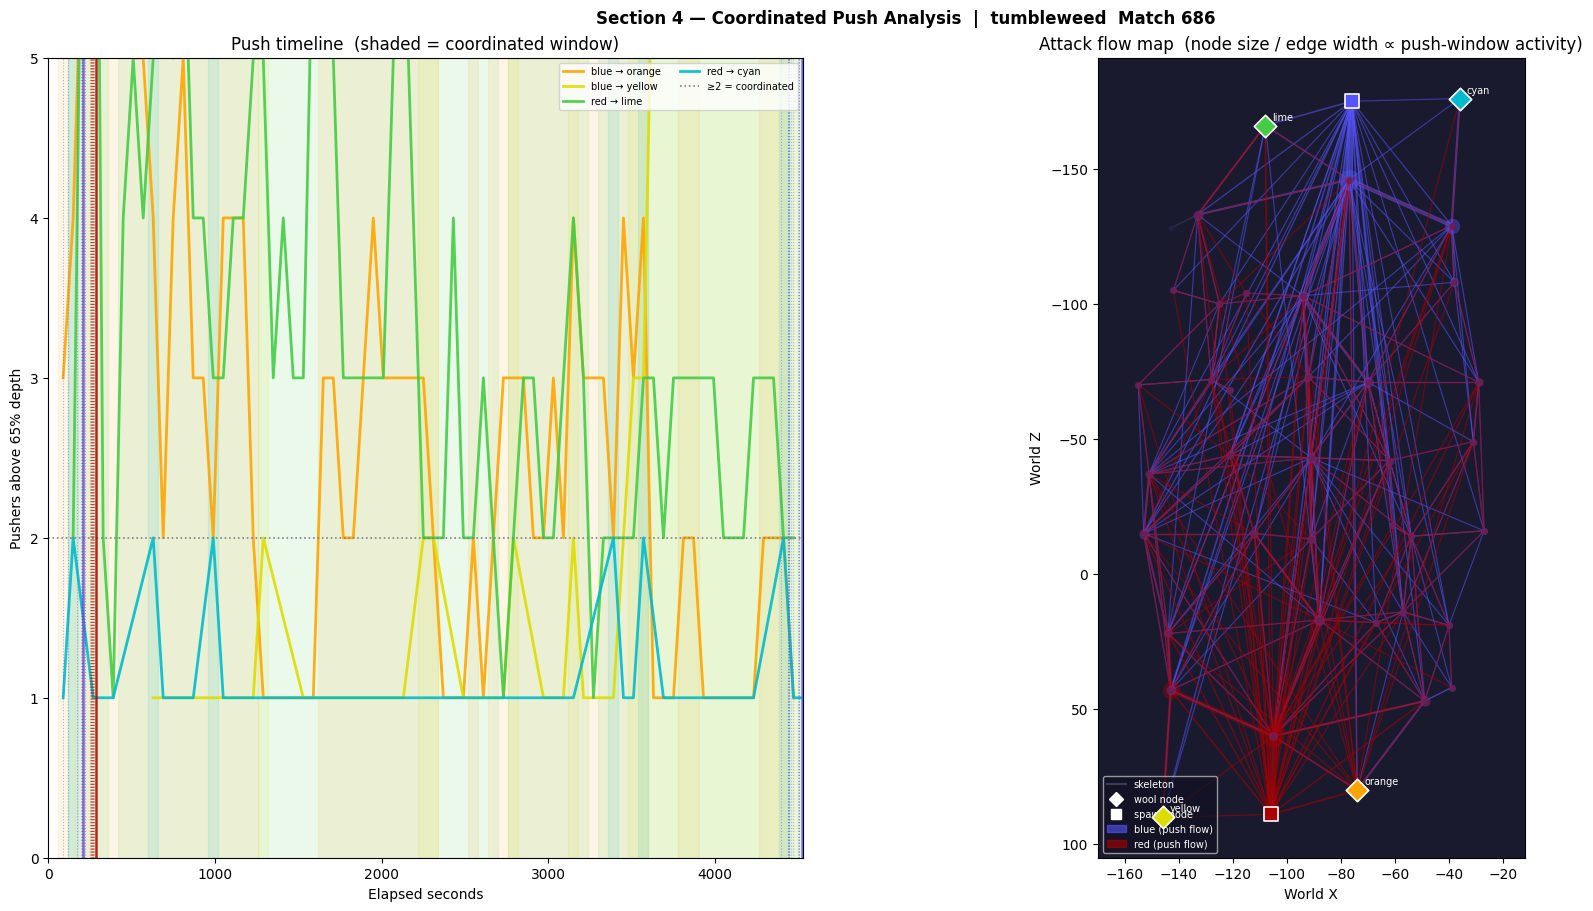

Saved: output\push_flow_match_686.png

=== Push Efficiency ===
team vs wool  push windows  touches in push  touches total  captures in push  captures total        hottest node  node ticks
blue  orange             6                8             14                 1               2 node #32 (skeleton)        4291
blue  yellow             5               10             14                 1               2 node #32 (skeleton)        4291
 red    lime             4               10             10                 1               1 node #35 (skeleton)        5522
 red    cyan             6                0             10                 0               1 node #35 (skeleton)        5522


In [6]:
# ── CONFIGURE ─────────────────────────────────────────────────────────────────
FLOW_MATCH_ID = INSPECT_MATCH_ID   # reuse from Section 1; change to inspect another
# ─────────────────────────────────────────────────────────────────────────────

from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

conn        = open_db()
flow_data   = load_match_data(conn, FLOW_MATCH_ID)
flow_colors = get_team_colors(conn, flow_data["map_id"])
conn.close()

flow_topo        = build_graph_topology(flow_data["map_slug"])
flow_counts      = compute_pusher_counts(flow_data, flow_topo, bucket_size_s=BUCKET_SIZE_S)
flow_teams       = sorted(flow_counts["team"].dropna().unique())
flow_wool_nodes  = flow_topo["wool_nodes"]
flow_node_info   = flow_topo["node_info"]
flow_match_dur   = flow_data["match_duration_s"]


# ── 1. Identify coordinated push windows {(team, wool_color): [(b_start, b_end)]} ──
push_windows: dict = {}
for team in flow_teams:
    for wn in flow_wool_nodes:
        if wn["team"] == team:
            continue
        wc  = wn["poi_color"]
        sub = (
            flow_counts[(flow_counts["team"] == team) & (flow_counts["wool_color"] == wc)]
            .sort_values("bucket")
        )
        windows: list = []
        for _, row in sub.iterrows():
            if row["pusher_count"] >= PUSH_MIN_PLAYERS:
                if windows and windows[-1][1] >= row["bucket"] - 1:
                    windows[-1] = (windows[-1][0], row["bucket"])
                else:
                    windows.append((row["bucket"], row["bucket"]))
        push_windows[(team, wc)] = windows


# ── 2. Node / edge occupation during push windows ─────────────────────────────
push_buckets_by_team: dict = {}
for (team, _), wins in push_windows.items():
    push_buckets_by_team.setdefault(team, set()).update(
        b for start, end in wins for b in range(start, end + 1)
    )

pos_enriched = add_graph_depth(flow_data["pos"].copy(), flow_topo)
pos_enriched["bucket"] = (pos_enriched["tick_t_s"] // BUCKET_SIZE_S).astype(int)

node_ticks: dict = {}   # {(team, map_node_id): tick count}
edge_ticks: dict = {}   # {(team, (a, b)): transition count}   a < b always

for team in flow_teams:
    push_bs = push_buckets_by_team.get(team, set())
    if not push_bs:
        continue
    sub = pos_enriched[
        (pos_enriched["team"] == team)
        & (pos_enriched["bucket"].isin(push_bs))
        & pos_enriched["nearest_graph_node"].notna()
    ].copy()

    for nid, grp in sub.groupby("nearest_graph_node"):
        node_ticks[(team, int(nid))] = len(grp)

    # Consecutive-row transitions per player
    sub_sorted = sub.sort_values(["player_id", "tick_t_s"])
    sub_sorted["prev_node"] = sub_sorted.groupby("player_id")["nearest_graph_node"].shift(1)
    transitions = sub_sorted[
        sub_sorted["prev_node"].notna()
        & (sub_sorted["nearest_graph_node"] != sub_sorted["prev_node"])
    ]
    for _, row in transitions.iterrows():
        a, b = int(row["prev_node"]), int(row["nearest_graph_node"])
        key  = (team, (min(a, b), max(a, b)))
        edge_ticks[key] = edge_ticks.get(key, 0) + 1


# ── 3. Figure ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), constrained_layout=True)
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1, 1.3])
ax_timeline = fig.add_subplot(gs[0, 0])
ax_flow     = fig.add_subplot(gs[0, 1])


# ── Panel A: Push timeline ─────────────────────────────────────────────────
for team in flow_teams:
    tc = flow_colors.get(team, "#888888")
    for wn in flow_wool_nodes:
        if wn["team"] == team:
            continue
        wc   = wn["poi_color"]
        wcol = _WOOL_PALETTE.get(wc, "#AAAAAA")
        sub  = flow_counts[
            (flow_counts["team"] == team) & (flow_counts["wool_color"] == wc)
        ].sort_values("bucket_mid_s")
        if sub.empty:
            continue
        ax_timeline.plot(
            sub["bucket_mid_s"], sub["pusher_count"],
            color=wcol, lw=2, alpha=0.9,
            label=f"{team} → {wc}",
        )
        for start_b, end_b in push_windows.get((team, wc), []):
            t0 = start_b * BUCKET_SIZE_S
            t1 = (end_b + 1) * BUCKET_SIZE_S
            ax_timeline.axvspan(t0, t1, color=wcol, alpha=0.10)

ax_timeline.axhline(
    PUSH_MIN_PLAYERS, color="grey", ls=":", lw=1.2,
    label=f"≥{PUSH_MIN_PLAYERS} = coordinated",
)

for team in flow_teams:
    tc      = flow_colors.get(team, "#888888")
    wool_ev = flow_data["wool"][flow_data["wool"]["team"] == team]
    for t in wool_ev[wool_ev["event_type"] == 6]["tick_t_s"].values:
        ax_timeline.axvline(t, color=tc, lw=0.8, alpha=0.45, ls=":")
    for t in wool_ev[wool_ev["event_type"] == 7]["tick_t_s"].values:
        ax_timeline.axvline(t, color=tc, lw=1.8, alpha=0.85)

ax_timeline.set_xlim(0, flow_match_dur + 5)
ax_timeline.set_ylim(0, max(PUSH_MIN_PLAYERS + 2, 5))
ax_timeline.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax_timeline.set_xlabel("Elapsed seconds")
ax_timeline.set_ylabel(f"Pushers above {PUSH_DEPTH_THRESHOLD:.0%} depth")
ax_timeline.set_title("Push timeline  (shaded = coordinated window)")
ax_timeline.legend(loc="upper right", fontsize=7, ncol=2)


# ── Panel B: Attack flow map ───────────────────────────────────────────────
# Gather all world coordinates for axis limits
all_coords = [
    n["coords"] for n in flow_node_info.values()
    if n.get("coords") is not None
]
if all_coords:
    cx_all = [c[0] for c in all_coords]
    cz_all = [c[1] for c in all_coords]
    pad    = 15
    xmin, xmax = min(cx_all) - pad, max(cx_all) + pad
    zmin, zmax = min(cz_all) - pad, max(cz_all) + pad
else:
    xmin, xmax, zmin, zmax = -200, 200, -200, 200

ax_flow.set_xlim(xmin, xmax)
ax_flow.set_ylim(zmax, zmin)   # invert Z: Minecraft +Z is south (down on most maps)
ax_flow.set_aspect("equal")
ax_flow.set_facecolor("#1a1a2e")
ax_flow.set_xlabel("World X")
ax_flow.set_ylabel("World Z")
ax_flow.set_title("Attack flow map  (node size / edge width ∝ push-window activity)")

# Draw structural skeleton (all islands, neutral grey)
for isl_id, G in flow_topo["island_graphs"].items():
    for u, v in G.edges():
        nu = flow_node_info.get(u, {})
        nv = flow_node_info.get(v, {})
        cu = nu.get("coords")
        cv = nv.get("coords")
        if cu is None or cv is None:
            continue
        ax_flow.plot(
            [cu[0], cv[0]], [cu[1], cv[1]],
            color="#3a3a5a", lw=0.9, alpha=0.7, zorder=1,
        )

# Draw attack-flow edges (team-coloured, width ∝ transitions)
max_edge_t = max(edge_ticks.values(), default=1)
for (team, edge_key), ticks in edge_ticks.items():
    tc = flow_colors.get(team, "#888888")
    a, b = edge_key
    na = flow_node_info.get(a, {})
    nb = flow_node_info.get(b, {})
    ca = na.get("coords")
    cb = nb.get("coords")
    if ca is None or cb is None:
        continue
    lw = 0.8 + 5.5 * ticks / max_edge_t
    ax_flow.plot(
        [ca[0], cb[0]], [ca[1], cb[1]],
        color=tc, lw=lw, alpha=0.55, zorder=2, solid_capstyle="round",
    )

# Draw base node dots
for nid, ndata in flow_node_info.items():
    coords = ndata.get("coords")
    if coords is None:
        continue
    ax_flow.scatter(coords[0], coords[1], s=12, color="#22224a", zorder=3, alpha=0.8)

# Draw team occupation rings (size ∝ ticks during push windows)
max_node_t = max(node_ticks.values(), default=1)
for team in flow_teams:
    tc = flow_colors.get(team, "#888888")
    for nid, ndata in flow_node_info.items():
        ticks = node_ticks.get((team, nid), 0)
        if ticks == 0:
            continue
        coords = ndata.get("coords")
        if coords is None:
            continue
        size = 25 + 250 * ticks / max_node_t
        ax_flow.scatter(
            coords[0], coords[1], s=size, color=tc,
            alpha=0.40, zorder=4, linewidths=0,
        )

# Highlight wool nodes (diamond, coloured by wool type)
for wn in flow_wool_nodes:
    nd = flow_node_info.get(wn["map_node_id"], {})
    coords = nd.get("coords")
    if coords is None:
        continue
    wc = _WOOL_PALETTE.get(wn["poi_color"], "#FFFFFF")
    ax_flow.scatter(
        coords[0], coords[1], s=130, color=wc, marker="D",
        edgecolors="white", linewidths=1.2, zorder=6,
    )
    ax_flow.annotate(
        wn["poi_color"], (coords[0], coords[1]),
        xytext=(5, 4), textcoords="offset points",
        color="white", fontsize=7, zorder=7,
    )

# Highlight spawn nodes (square, coloured by team)
for sn in flow_topo["spawn_nodes"]:
    nd = flow_node_info.get(sn["map_node_id"], {})
    coords = nd.get("coords")
    if coords is None:
        continue
    tc = flow_colors.get(sn.get("team", ""), "#888888")
    ax_flow.scatter(
        coords[0], coords[1], s=90, color=tc, marker="s",
        edgecolors="white", linewidths=1.2, zorder=6,
    )

# Legend
legend_els = [
    Line2D([0], [0], color="#3a3a5a", lw=1.5, label="skeleton"),
    Line2D([0], [0], color="white", lw=0, marker="D", ms=7, label="wool node"),
    Line2D([0], [0], color="white", lw=0, marker="s", ms=7, label="spawn node"),
]
for team in flow_teams:
    tc = flow_colors.get(team, "#888888")
    legend_els.append(
        mpatches.Patch(color=tc, alpha=0.6, label=f"{team} (push flow)")
    )
ax_flow.legend(
    handles=legend_els, loc="lower left", fontsize=7,
    facecolor="#111122", labelcolor="white", framealpha=0.7,
)

fig.suptitle(
    f"Section 4 — Coordinated Push Analysis  |  "
    f"{flow_data['map_slug']}  Match {FLOW_MATCH_ID}",
    fontsize=12, fontweight="bold",
)

out_path = OUTPUT_DIR / f"push_flow_match_{FLOW_MATCH_ID}.png"
fig.savefig(out_path, dpi=130, bbox_inches="tight", facecolor="#0d0d1a")
plt.show()
print(f"Saved: {out_path}")


# ── Panel C: Push efficiency table ─────────────────────────────────────────
def _in_push(t: float, wins: list) -> bool:
    return any(
        start * BUCKET_SIZE_S <= t <= (end + 1) * BUCKET_SIZE_S
        for start, end in wins
    )

eff_rows = []
for (team, wc), wins in push_windows.items():
    wool_ev    = flow_data["wool"][flow_data["wool"]["team"] == team]
    touches_t  = wool_ev[wool_ev["event_type"] == 6]["tick_t_s"].values
    captures_t = wool_ev[wool_ev["event_type"] == 7]["tick_t_s"].values

    team_nodes = {nid: v for (tm, nid), v in node_ticks.items() if tm == team}
    if team_nodes:
        best_nid   = max(team_nodes, key=team_nodes.get)
        best_ticks = team_nodes[best_nid]
        best_poi   = flow_node_info.get(best_nid, {}).get("poi_type") or "skeleton"
        best_label = f"node #{best_nid} ({best_poi})"
    else:
        best_ticks, best_label = 0, "—"

    eff_rows.append({
        "team":             team,
        "vs wool":          wc,
        "push windows":     len(wins),
        "touches in push":  int(sum(_in_push(t, wins) for t in touches_t)),
        "touches total":    len(touches_t),
        "captures in push": int(sum(_in_push(t, wins) for t in captures_t)),
        "captures total":   len(captures_t),
        "hottest node":     best_label,
        "node ticks":       best_ticks,
    })

eff_df = pd.DataFrame(eff_rows) if eff_rows else pd.DataFrame()
print("\n=== Push Efficiency ===")
if not eff_df.empty:
    print(eff_df.to_string(index=False))
else:
    print("  (no coordinated push windows found)")